<a href="https://colab.research.google.com/github/kushim2005/omniproject/blob/main/SubAgents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install sentence-transformers faiss-cpu langchain
import faiss
import pickle
import numpy as np

from sentence_transformers import SentenceTransformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 69.6 MB/s eta 0:00:00


In [4]:
print("Loading embedding model...")

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully.")

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.


In [5]:
index = faiss.read_index(
    "/content/drive/MyDrive/Project folder/faiss_index.bin"
)

with open(
    "/content/drive/MyDrive/Project folder/metadata.pkl",
    "rb"
) as f:
    metadata = pickle.load(f)

print("Documents Loaded:", len(metadata))

Documents Loaded: 488


In [6]:
def search_vector_db(query, k=3):

    # Convert query into embedding
    query_embedding = model.encode([query])

    # Search FAISS
    distances, indices = index.search(
        np.array(query_embedding).astype("float32"),
        k
    )

    results = []

    for idx in indices[0]:

        if idx != -1:
            results.append(metadata[idx]["text"])

    return results

In [7]:
def pdf_agent(query):

    documents = search_vector_db(query)

    if len(documents) == 0:
        return {
            "agent": "PDF Agent",
            "answer": "No relevant information found."
        }

    context = "\n\n".join(documents)

    return {
        "agent": "PDF Agent",
        "answer": context
    }

In [8]:
result = pdf_agent("What is Machine Learning?")

print(result["agent"])
print()
print(result["answer"])

PDF Agent

 of the model using the training data or 
past experience. The model may be predictive to make predictions in the future, or descriptive to gain 
knowledge from data, or both. 
Arthur Samuel, an early American leader in the field of computer gaming and artificial intelligence, 
coined the term “Machine Learning” in 1959 while at IBM. He defined machine learning as “the field of 
study that gives computers the ability to learn without being explicitly programmed.” However, there is 
no universall

y accepted definition for machine learning. Different authors define the term differently. 
 
Definition of learning 
Definition 
A computer program is said to learn from experience E with respect to some class of tasks T and 
performance measure P, if its performance at tasks T, as measured by P, improves with experience E. 
 
Examples 
i) Handwriting recognition learning problem 
• Task T: Recognising and classifying handwritten words within images 
• Performance P: Percent of wor

In [14]:
import json
import os

# Updated path after moving the folder to Google Drive
base_drive_path = "/content/drive/MyDrive/Project folder/output"
metadata_path = os.path.join(base_drive_path, "metadata.json")

with open(metadata_path, "r") as f:
    image_metadata = json.load(f)

# Update the saved_path for each image to reflect the new location
for img in image_metadata:
    # Replace the relative 'output/' with the full drive path
    if img['saved_path'].startswith('output/'):
        img['saved_path'] = img['saved_path'].replace('output/', base_drive_path + '/')

print(f"Total Images: {len(image_metadata)}")
print(f"Sample path: {image_metadata[0]['saved_path']}")

Total Images: 169
Sample path: /content/drive/MyDrive/Project folder/output/images/img_p001_01.png


In [11]:
from PIL import Image
from IPython.display import display

In [15]:
def image_agent(query):

    if len(image_metadata) == 0:
        return {
            "agent": "Image Agent",
            "answer": "No images available."
        }

    # Temporary: show the first extracted image
    image = image_metadata[0]

    img = Image.open(image["saved_path"])
    display(img)

    return {
        "agent": "Image Agent",
        "page_number": image["page_number"],
        "image_path": image["saved_path"],
        "answer": "Image displayed successfully."
    }

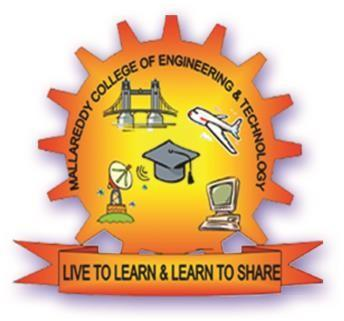

{'agent': 'Image Agent', 'page_number': 1, 'image_path': '/content/drive/MyDrive/Project folder/output/images/img_p001_01.png', 'answer': 'Image displayed successfully.'}


In [16]:
result = image_agent("Show the architecture diagram")

print(result)

In [17]:
def greeting_agent(query):

    greetings = ["hi", "hello", "hey", "good morning", "good evening"]

    if any(word in query.lower() for word in greetings):
        return {
            "agent": "Greeting Agent",
            "answer": "Hello! How can I help you today?"
        }

    return None

In [18]:
def general_agent(query):

    return {
        "agent": "General Agent",
        "answer": f"I received your query: '{query}'. This query is not related to the PDF or images."
    }

In [19]:
def router(query):

    q = query.lower().strip()

    # Greeting (match complete greetings)
    if q in ["hi", "hello", "hey", "good morning", "good evening"]:
        return greeting_agent(query)

    # Image queries
    elif any(keyword in q for keyword in [
        "image",
        "figure",
        "diagram",
        "architecture",
        "graph",
        "flowchart"
    ]):
        return image_agent(query)

    # PDF queries
    elif any(keyword in q for keyword in [
        "machine learning",
        "supervised",
        "unsupervised",
        "reinforcement",
        "deep learning",
        "ann",
        "cnn",
        "svm",
        "knn",
        "naive bayes",
        "decision tree",
        "logistic regression"
    ]):
        return pdf_agent(query)

    # Everything else
    else:
        return general_agent(query)

In [20]:
print("===== Greeting Agent =====")

result = router("Hello")

print(result)

===== Greeting Agent =====
{'agent': 'Greeting Agent', 'answer': 'Hello! How can I help you today?'}


In [21]:
print("===== PDF Agent =====")

result = router("What is supervised learning?")

print(result["agent"])
print()
print(result["answer"])

===== PDF Agent =====
PDF Agent

puts. This is also called 
learning from exemplars. Supervised learning is the machine learning task of learning a function that 
maps an input to an output based on example input-output pairs. 
 
In supervised learning, each example in the training set is a pair consisting of an input object 
(typically a vector) and an output value. A supervised learning algorithm analyzes the training data and 
produces a function, which can be used for mapping new examples. In the optimal case, the function 

ed learning is to find the hidden patterns and 
useful insights from the unknown dataset. 
Supervised learning needs supervision to train the model. 
Unsupervised learning does not need any supervision to train the 
model. 
Supervised learning can be categorized 
in Classification and Regression problems. 
Unsupervised Learning can be classified 
in Clustering and Associations problems. 
Supervised learning can be used for those cases where we know the input 
a

In [22]:
print("===== General Agent =====")

result = router("Tell me a joke")

print(result)

===== General Agent =====
{'agent': 'General Agent', 'answer': "I received your query: 'Tell me a joke'. This query is not related to the PDF or images."}


User: Hello
Agent: Greeting Agent
Answer: Hello! How can I help you today?
User: What is Machine Learning?
Agent: PDF Agent
Answer:  of the model using the training data or 
past experience. The model may be predictive to make predictions in the future, or descriptive to gain 
knowledge from data, or both. 
Arthur Samuel, an early American leader in the field of computer gaming and artificial intelligence, 
coined the term “Machine Learning” in 1959 while at IBM. He defined machine learning as “the field of 
study that gives computers the ability to learn without being explicitly programmed.” However, there is 
no universall

y accepted definition for machine learning. Different authors define the term differently. 
 
Definition of learning 
Definition 
A computer program is said to learn from experience E with respect to some class of tasks T and 
performance measure P, if its performance at tasks T, as measured by P, improves with experience E. 
 
Examples 
i) Handwriting recognition

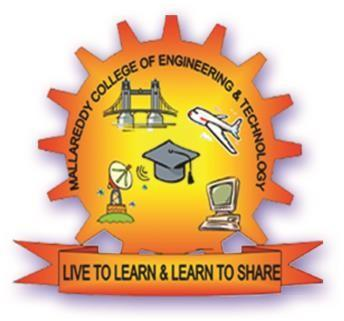

Agent: Image Agent
Answer: Image displayed successfully.
User: Tell me a joke
Agent: General Agent
Answer: I received your query: 'Tell me a joke'. This query is not related to the PDF or images.


In [23]:
queries = [
    "Hello",
    "What is Machine Learning?",
    "Explain supervised learning",
    "Show the architecture diagram",
    "Tell me a joke"
]

for query in queries:
    print("=" * 60)
    print("User:", query)

    response = router(query)

    print("Agent:", response["agent"])
    print("Answer:", response["answer"])